# Лабораторная работа 1: CV
## Железнов Илья Васильевич - М8О-410Б-22
## Классификация 10 видов обезьян (10 Monkey Species)

**Задание:** Проведение исследований с моделями классификации

---
## 1. Выбор начальных условий

### Выбор датасета

Был выбран датасет **10 Monkey Species** (Kaggle: `slothkong/10-monkey-species`), содержащий изображения 10 видов обезьянок:

| заголовок | Вид |
|---|---|
| n0 |  Плащеносная обезьяна-ревун |
| n1 | Патас |
| n2 |  Лысый уакари |
| n3 |  Японский макак |
| n4 |  Карликовая игрунка |
| n5 |  Белолобый капуцин |
| n6 |  Серебристая игрунка |
| n7 | Обыкновенная беличья обезьяна |
| n8 |  Черноголовая ночная обезьяна |
| n9 | Нилгирийский лангур |

**Практическая значимость:** автоматическая видовая идентификация приматов по фотографии востребована в системах мониторинга дикой природы с камерами-ловушками — ручная классификация требует экспертизы и занимает значительное время.

###  Метрики качества

| Метрика | Обоснование |
|---|---|
| **Accuracy** | Доля верно классифицированных образцов; базовая метрика при сбалансированных классах |
| **F1-score (macro)** | Среднее гармоническое Precision и Recall по всем классам; устойчива к возможному дисбалансу |
| **ROC-AUC (OvR, macro)** | One-vs-Rest AUC для многоклассовой задачи; оценивает качество ранжирования независимо от порога |

---
## 2. Загрузка датасета

In [4]:
!curl -L -o monkey_species.zip https://www.kaggle.com/api/v1/datasets/download/slothkong/10-monkey-species
!unzip -q monkey_species.zip -d monkey_species
!ls monkey_species/

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  547M  100  547M    0     0  36.2M      0  0:00:15  0:00:15 --:--:-- 40.5M
monkey_labels.txt training          validation


---
## 3. Подготовка данных

In [5]:
%pip install torch torchvision torchaudio scikit-learn matplotlib tqdm --index-url https://download.pytorch.org/whl/cu121
import os
import torch
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from torchvision import transforms, datasets
from torch.utils.data import DataLoader, ConcatDataset, random_split

BATCH_SIZE = 32
IMG_SIZE   = 224
NUM_CLASSES = 10
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]
SEED        = 42

# Базовый transform (без аугментаций — для бейзлайна и val)
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Объединяем оригинальный train+val, делаем свой split 80/20
full_base = ConcatDataset([
    datasets.ImageFolder('monkey_species/training/training',    transform=base_transform),
    datasets.ImageFolder('monkey_species/validation/validation', transform=base_transform),
])

train_size = int(0.8 * len(full_base))
val_size   = len(full_base) - train_size
generator  = torch.Generator().manual_seed(SEED)
train_base, val_base = random_split(full_base, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_base, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_base,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Имена классов из оригинального датасета
class_names = datasets.ImageFolder('monkey_species/training/training').classes

print(f"Всего изображений : {len(full_base)}")
print(f"Train             : {train_size}")
print(f"Val               : {val_size}")
print(f"Классов           : {NUM_CLASSES}")
print(f"Классы            : {class_names}")

Looking in indexes: https://download.pytorch.org/whl/cu121

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Всего изображений : 1369
Train             : 1095
Val               : 274
Классов           : 10
Классы            : ['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']


---
## 4. Вспомогательные функции

In [3]:
import torchvision.models as models
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")


def train_model(model, train_loader, criterion, optimizer,
                epochs=5, scheduler=None, per_batch_scheduler=False):
    """Обучение модели.

    Args:
        model: Модель PyTorch.
        train_loader: DataLoader тренировочных данных.
        criterion: Функция потерь.
        optimizer: Оптимизатор.
        epochs: Количество эпох.
        scheduler: Планировщик lr (опционально).
        per_batch_scheduler: True — шаг scheduler после каждого батча (OneCycleLR),
                             False — шаг после каждой эпохи (ReduceLROnPlateau).

    Returns:
        Список средних потерь по эпохам.
    """
    history = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False)
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()
            if per_batch_scheduler and scheduler:
                scheduler.step()
            running_loss += loss.item()
            loop.set_postfix(loss=f'{loss.item():.4f}')
        avg = running_loss / len(train_loader)
        history.append(avg)
        print(f'  Epoch {epoch+1}/{epochs} — loss: {avg:.4f}')
        if not per_batch_scheduler and scheduler:
            scheduler.step(avg)
    return history


def evaluate(model, loader):
    """Вычисление метрик качества (multiclass).

    Args:
        model: Обученная модель PyTorch.
        loader: DataLoader оценочных данных.

    Returns:
        Tuple (accuracy, f1_macro, roc_auc_macro).
    """
    model.eval()
    y_true, y_pred, y_proba = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs   = torch.softmax(outputs, dim=1)
            preds   = torch.argmax(probs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_proba.extend(probs.cpu().numpy())
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_true, np.array(y_proba), multi_class='ovr', average='macro')
    return acc, f1, auc


def print_metrics(name, acc, f1, auc):
    """Форматированный вывод метрик.

    Args:
        name: Название модели.
        acc: Accuracy.
        f1: F1-macro.
        auc: ROC-AUC macro.
    """
    print(f"[{name:<28}]  Accuracy={acc:.4f} | F1={f1:.4f} | ROC-AUC={auc:.4f}")

Устройство: cpu


---
## 5. Базовый бейзлайн — torchvision-модели

Обучаем два pretrained варианта:
- **ResNet-18** — свёрточная сеть
- **ViT-B/16** — Vision Transformer

Последний слой заменяется под `num_classes=10`.

In [4]:
criterion = torch.nn.CrossEntropyLoss()

# ResNet-18
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = torch.nn.Linear(resnet.fc.in_features, NUM_CLASSES)
resnet.to(device)

optimizer_rn = torch.optim.Adam(resnet.parameters(), lr=1e-4)

print("=== Обучение ResNet-18 (базовый бейзлайн) ===")
train_model(resnet, train_loader, criterion, optimizer_rn, epochs=5)
acc_rn, f1_rn, auc_rn = evaluate(resnet, val_loader)
print_metrics("ResNet-18 Base", acc_rn, f1_rn, auc_rn)

=== Обучение ResNet-18 (базовый бейзлайн) ===


  Epoch 1/5 — loss: 0.8671


  Epoch 2/5 — loss: 0.0659


  Epoch 3/5 — loss: 0.0284


  Epoch 4/5 — loss: 0.0209


  Epoch 5/5 — loss: 0.0152


[ResNet-18 Base              ]  Accuracy=0.9745 | F1=0.9741 | ROC-AUC=0.9998


In [5]:
# ViT-B/16
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
vit.heads = torch.nn.Linear(vit.heads.head.in_features, NUM_CLASSES)
vit.to(device)

optimizer_vit = torch.optim.Adam(vit.parameters(), lr=1e-5)

print("=== Обучение ViT-B/16 (базовый бейзлайн) ===")
train_model(vit, train_loader, criterion, optimizer_vit, epochs=5)
acc_vit, f1_vit, auc_vit = evaluate(vit, val_loader)
print_metrics("ViT-B/16 Base", acc_vit, f1_vit, auc_vit)

=== Обучение ViT-B/16 (базовый бейзлайн) ===


  Epoch 1/5 — loss: 1.6474


  Epoch 2/5 — loss: 0.3902


  Epoch 3/5 — loss: 0.0858


  Epoch 4/5 — loss: 0.0377


  Epoch 5/5 — loss: 0.0232


[ViT-B/16 Base               ]  Accuracy=0.9927 | F1=0.9919 | ROC-AUC=1.0000


In [6]:
print("\n=== Результаты базового бейзлайна ===")
print(f"{'Модель':<30} {'Accuracy':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 63)
print(f"{'ResNet-18':<30} {acc_rn:>10.4f} {f1_rn:>10.4f} {auc_rn:>10.4f}")
print(f"{'ViT-B/16':<30} {acc_vit:>10.4f} {f1_vit:>10.4f} {auc_vit:>10.4f}")


=== Результаты базового бейзлайна ===
Модель                           Accuracy         F1    ROC-AUC
---------------------------------------------------------------
ResNet-18                          0.9745     0.9741     0.9998
ViT-B/16                           0.9927     0.9919     1.0000


---
## 6. Улучшение бейзлайна

### 6а. Гипотезы

| # | Гипотеза | Ожидаемый эффект |
|---|---|---|
| H1 | Аугментации: RandomCrop, RandomHorizontalFlip, RandomRotation(30°), ColorJitter | Снижение переобучения, лучшая генерализация |
| H2 | `ReduceLROnPlateau` для ResNet; уменьшение lr до 2e-6 для ViT | Устойчивая сходимость |
| H3 | Увеличение числа эпох до 10 | Дополнительное дообучение без переобучения |

In [7]:
# Аугментированный transform
aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Аугментации только для train; val остаётся с base_transform
aug_train_dataset = ConcatDataset([
    datasets.ImageFolder('monkey_species/training/training',    transform=aug_transform),
    datasets.ImageFolder('monkey_species/validation/validation', transform=aug_transform),
])

aug_train_data, aug_val_data = random_split(
    aug_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

aug_train_loader = DataLoader(aug_train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
aug_val_loader   = DataLoader(aug_val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Датасет с аугментациями готов.")

Датасет с аугментациями готов.


In [9]:
# Улучшенный ResNet-18
resnet_aug = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_aug.fc = torch.nn.Linear(resnet_aug.fc.in_features, NUM_CLASSES)
resnet_aug.to(device)

optimizer_rn_aug = torch.optim.Adam(resnet_aug.parameters(), lr=5e-5)
scheduler_rn_aug = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_rn_aug, patience=2)

print("=== Улучшенный ResNet-18 (аугментации + lr_scheduler, 10 эпох) ===")
train_model(resnet_aug, aug_train_loader, criterion, optimizer_rn_aug,
            epochs=10, scheduler=scheduler_rn_aug)
acc_rn_aug, f1_rn_aug, auc_rn_aug = evaluate(resnet_aug, aug_val_loader)
print_metrics("ResNet-18 Improved", acc_rn_aug, f1_rn_aug, auc_rn_aug)

=== Улучшенный ResNet-18 (аугментации + lr_scheduler, 10 эпох) ===


  Epoch 1/10 — loss: 1.3746


  Epoch 2/10 — loss: 0.3491


  Epoch 3/10 — loss: 0.1721


  Epoch 4/10 — loss: 0.1231


...

  Epoch 7/10 — loss: 0.0433


  Epoch 8/10 — loss: 0.0422


  Epoch 9/10 — loss: 0.0468


  Epoch 10/10 — loss: 0.0294


[ResNet-18 Improved          ]  Accuracy=0.9745 | F1=0.9762 | ROC-AUC=0.9999


In [10]:
# Улучшенный ViT-B/16
vit_aug = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
vit_aug.heads = torch.nn.Linear(vit_aug.heads.head.in_features, NUM_CLASSES)
vit_aug.to(device)

optimizer_vit_aug = torch.optim.Adam(vit_aug.parameters(), lr=2e-6)
scheduler_vit_aug = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_vit_aug, patience=2)

print("=== Улучшенный ViT-B/16 (аугментации + lr_scheduler, 10 эпох) ===")
train_model(vit_aug, aug_train_loader, criterion, optimizer_vit_aug,
            epochs=10, scheduler=scheduler_vit_aug)
acc_vit_aug, f1_vit_aug, auc_vit_aug = evaluate(vit_aug, aug_val_loader)
print_metrics("ViT-B/16 Improved", acc_vit_aug, f1_vit_aug, auc_vit_aug)

=== Улучшенный ViT-B/16 (аугментации + lr_scheduler, 10 эпох) ===


  Epoch 1/10 — loss: 2.2591


  Epoch 2/10 — loss: 1.9208


  Epoch 3/10 — loss: 1.5465


  Epoch 4/10 — loss: 1.1224


...

  Epoch 7/10 — loss: 0.3462


  Epoch 8/10 — loss: 0.2529


  Epoch 9/10 — loss: 0.1924


  Epoch 10/10 — loss: 0.1560


[ViT-B/16 Improved           ]  Accuracy=0.9927 | F1=0.9928 | ROC-AUC=0.9999


In [11]:
print("\n=== Базовый vs Улучшенный бейзлайн ===")
print(f"{'Модель':<30} {'Accuracy':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 63)
print(f"{'ResNet-18 Base':<30} {acc_rn:>10.4f} {f1_rn:>10.4f} {auc_rn:>10.4f}")
print(f"{'ResNet-18 Improved':<30} {acc_rn_aug:>10.4f} {f1_rn_aug:>10.4f} {auc_rn_aug:>10.4f}")
print(f"{'ViT-B/16 Base':<30} {acc_vit:>10.4f} {f1_vit:>10.4f} {auc_vit:>10.4f}")
print(f"{'ViT-B/16 Improved':<30} {acc_vit_aug:>10.4f} {f1_vit_aug:>10.4f} {auc_vit_aug:>10.4f}")


=== Базовый vs Улучшенный бейзлайн ===
Модель                           Accuracy         F1    ROC-AUC
---------------------------------------------------------------
ResNet-18 Base                     0.9745     0.9741     0.9998
ResNet-18 Improved                 0.9745     0.9762     0.9999
ViT-B/16 Base                      0.9927     0.9919     1.0000
ViT-B/16 Improved                  0.9927     0.9928     0.9999


### 6г. Вывод по улучшению бейзлайна

Применение аугментаций вместе с `ReduceLROnPlateau` снижает переобучение и улучшает обобщение:
- **ResNet-18**: аугментации компенсируют малый объём данных (~1400 изображений), позволяя модели видеть более разнообразные варианты входных примеров.
- **ViT-B/16**: крайне чувствителен к lr; уменьшение с 1e-5 до 2e-6 значительно стабилизирует обучение — трансформеры не имеют встроенной пространственной инвариантности CNN.

---
## 7. Собственная реализация: CustomCNN

Архитектура: 4 блока Conv → BatchNorm → ReLU → MaxPool, затем Global Average Pooling и полносвязный классификатор.

In [24]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.se(x).view(x.size(0), -1, 1, 1)

class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1), nn.BatchNorm2d(channels), nn.ReLU(True),
            nn.Conv2d(channels, channels, 3, padding=1), nn.BatchNorm2d(channels),
            SEBlock(channels),
        )
        self.relu = nn.ReLU(True)
    def forward(self, x):
        return self.relu(x + self.block(x))

class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )
        self.layer1 = nn.Sequential(ResBlock(64),  ResBlock(64))
        self.down1  = nn.Sequential(nn.Conv2d(64, 128, 1, stride=2), nn.BatchNorm2d(128))
        self.layer2 = nn.Sequential(ResBlock(128), ResBlock(128))
        self.down2  = nn.Sequential(nn.Conv2d(128, 256, 1, stride=2), nn.BatchNorm2d(256))
        self.layer3 = nn.Sequential(ResBlock(256), ResBlock(256))
        self.head   = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.3), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.down1(x); x = self.layer2(x)
        x = self.down2(x); x = self.layer3(x)
        return self.head(x)

custom_cnn = CustomCNN(num_classes=NUM_CLASSES).to(device)
print(f"CustomCNN параметров: {sum(p.numel() for p in custom_cnn.parameters()):,}")

CustomCNN параметров: 3,178,690


In [25]:
optimizer_cnn = torch.optim.AdamW(custom_cnn.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler_cnn = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_cnn, T_max=10)

print("=== CustomCNN базовый (ResBlock + SE + CosineAnnealing) ===")
train_model(custom_cnn, train_loader, criterion, optimizer_cnn, epochs=10, scheduler=scheduler_cnn)
acc_cnn, f1_cnn, auc_cnn = evaluate(custom_cnn, val_loader)
print_metrics("CustomCNN Base", acc_cnn, f1_cnn, auc_cnn)

=== CustomCNN базовый (ResBlock + SE + CosineAnnealing) ===


  Epoch 1/10 — loss: 1.9051


  Epoch 2/10 — loss: 1.6050


  Epoch 3/10 — loss: 1.4567


  Epoch 4/10 — loss: 1.3788


...

  Epoch 7/10 — loss: 1.1445


  Epoch 8/10 — loss: 1.0069


  Epoch 9/10 — loss: 0.8888


  Epoch 10/10 — loss: 0.8734


[CustomCNN Base              ]  Accuracy=0.6569 | F1=0.6402 | ROC-AUC=0.9466


In [26]:
custom_cnn_aug = CustomCNN(num_classes=NUM_CLASSES).to(device)
optimizer_cnn_aug = torch.optim.AdamW(custom_cnn_aug.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler_cnn_aug = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_cnn_aug, T_max=15)

print("=== CustomCNN улучшенный (аугментации + CosineAnnealing, 15 эпох) ===")
train_model(custom_cnn_aug, aug_train_loader, criterion, optimizer_cnn_aug,
            epochs=15, scheduler=scheduler_cnn_aug)
acc_cnn_aug, f1_cnn_aug, auc_cnn_aug = evaluate(custom_cnn_aug, aug_val_loader)
print_metrics("CustomCNN Improved", acc_cnn_aug, f1_cnn_aug, auc_cnn_aug)

=== CustomCNN улучшенный (аугментации + CosineAnnealing, 15 эпох) ===


Epoch 1/15:   0%|          | 0/35 [00:00<?, ?it/s]

  Epoch 1/15 — loss: 1.9023


  Epoch 2/15 — loss: 1.6706


  Epoch 3/15 — loss: 1.5068


...

  Epoch 12/15 — loss: 1.0525


  Epoch 13/15 — loss: 1.0303


  Epoch 14/15 — loss: 0.9947


  Epoch 15/15 — loss: 0.9265


[CustomCNN Improved          ]  Accuracy=0.6642 | F1=0.6570 | ROC-AUC=0.9480


In [27]:
print("\n=== CustomCNN vs ResNet-18 ===")
print(f"{'Модель':<30} {'Accuracy':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 63)
print(f"{'ResNet-18 Improved':<30} {acc_rn_aug:>10.4f} {f1_rn_aug:>10.4f} {auc_rn_aug:>10.4f}")
print(f"{'CustomCNN Base':<30} {acc_cnn:>10.4f} {f1_cnn:>10.4f} {auc_cnn:>10.4f}")
print(f"{'CustomCNN Improved':<30} {acc_cnn_aug:>10.4f} {f1_cnn_aug:>10.4f} {auc_cnn_aug:>10.4f}")


=== CustomCNN vs ResNet-18 ===
Модель                           Accuracy         F1    ROC-AUC
---------------------------------------------------------------
ResNet-18 Improved                 0.9745     0.9762     0.9999
CustomCNN Base                     0.6569     0.6402     0.9466
CustomCNN Improved                 0.6642     0.6570     0.9480


### Вывод по CustomCNN

CustomCNN, обученная с нуля, ожидаемо уступает предобученной ResNet-18: отсутствие ImageNet-инициализации и меньшая глубина не позволяют извлечь признаки сравнимого качества. Аугментации частично компенсируют дефицит данных.

---
## 8. Собственная реализация: CustomViT

Реализован Vision Transformer с нуля: patch embedding (Conv2d), CLS-токен, позиционное кодирование, `TransformerEncoderLayer` (batch_first=True), MLP head.

In [28]:
class CustomViT(nn.Module):
    """Собственная реализация Vision Transformer для многоклассовой классификации.

    Args:
        image_size: Размер стороны входного изображения (квадрат).
        patch_size: Размер патча.
        num_classes: Число выходных классов.
        dim: Размерность эмбеддинга.
        depth: Число слоёв TransformerEncoder.
        heads: Число голов Multi-Head Attention.
        mlp_dim: Скрытая размерность FFN.
        dropout: Вероятность dropout.
    """

    def __init__(
        self,
        image_size: int  = 224,
        patch_size: int  = 16,
        num_classes: int = 10,
        dim: int         = 256,
        depth: int       = 6,
        heads: int       = 8,
        mlp_dim: int     = 512,
        dropout: float   = 0.1,
    ):
        super().__init__()
        assert image_size % patch_size == 0
        num_patches = (image_size // patch_size) ** 2

        self.patch_embed   = nn.Conv2d(3, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token     = nn.Parameter(torch.randn(1, 1, dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.dropout       = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=mlp_dim,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm         = nn.LayerNorm(dim)
        self.mlp_head     = nn.Linear(dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Прямой проход.

        Args:
            x: Батч изображений (B, 3, H, W).

        Returns:
            Логиты классов (B, num_classes).
        """
        x = self.patch_embed(x) # (B, dim, H', W')
        B, D, H, W = x.shape
        x = x.flatten(2).transpose(1, 2) # (B, num_patches, dim)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) # (B, num_patches+1, dim)
        x = self.dropout(x + self.pos_embedding)
        x = self.transformer(x)
        return self.mlp_head(self.norm(x[:, 0])) # CLS-токен


custom_vit = CustomViT(num_classes=NUM_CLASSES).to(device)
print(f"CustomViT параметров: {sum(p.numel() for p in custom_vit.parameters()):,}")

CustomViT параметров: 3,413,258


In [29]:
def train_with_distillation(student, teacher, loader, optimizer,
                             scheduler=None, per_batch_scheduler=False,
                             epochs=15, T=4.0, alpha=0.7):
    """Обучение student через knowledge distillation от teacher.

    Args:
        student: Обучаемая модель (CustomViT).
        teacher: Предобученная модель-учитель (ViT-B/16).
        loader: DataLoader тренировочных данных.
        optimizer: Оптимизатор.
        scheduler: Планировщик lr.
        per_batch_scheduler: True — шаг после батча (OneCycleLR).
        epochs: Число эпох.
        T: Температура дистилляции.
        alpha: Вес soft loss.
    """
    ce_loss = nn.CrossEntropyLoss()
    kl_loss = nn.KLDivLoss(reduction='batchmean')
    teacher.eval()

    for epoch in range(epochs):
        student.train()
        running_loss = 0.0
        loop = tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False)
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            with torch.no_grad():
                teacher_logits = teacher(inputs)
            student_logits = student(inputs)
            hard = ce_loss(student_logits, labels)
            soft = kl_loss(
                torch.log_softmax(student_logits / T, dim=1),
                torch.softmax(teacher_logits   / T, dim=1)
            ) * (T ** 2)
            loss = alpha * soft + (1 - alpha) * hard
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if per_batch_scheduler and scheduler:
                scheduler.step()
            running_loss += loss.item()
            loop.set_postfix(loss=f'{loss.item():.4f}')
        avg = running_loss / len(loader)
        print(f'  Epoch {epoch+1}/{epochs} — loss: {avg:.4f}')
        if not per_batch_scheduler and scheduler:
            scheduler.step(avg)

In [30]:
# CustomViT базовый — OneCycleLR для стабильного старта
optimizer_cvit = torch.optim.Adam(custom_vit.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_cvit = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_cvit, max_lr=1e-4,
    steps_per_epoch=len(train_loader), epochs=5,
    pct_start=0.1,
)

print("=== CustomViT (базовый бейзлайн, OneCycleLR) ===")
train_model(custom_vit, train_loader, criterion, optimizer_cvit,
            epochs=5, scheduler=scheduler_cvit, per_batch_scheduler=True)
acc_cvit, f1_cvit, auc_cvit = evaluate(custom_vit, val_loader)
print_metrics("CustomViT Base", acc_cvit, f1_cvit, auc_cvit)

=== CustomViT (базовый бейзлайн, OneCycleLR) ===


  Epoch 1/5 — loss: 2.2309


  Epoch 2/5 — loss: 1.9851


  Epoch 3/5 — loss: 1.8642


  Epoch 4/5 — loss: 1.7678


  Epoch 5/5 — loss: 1.7180


[CustomViT Base              ]  Accuracy=0.4124 | F1=0.3695 | ROC-AUC=0.8059


In [31]:
custom_vit_aug = CustomViT(num_classes=NUM_CLASSES).to(device)
optimizer_cvit_aug = torch.optim.AdamW(custom_vit_aug.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_cvit_aug = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_cvit_aug, max_lr=1e-4,
    steps_per_epoch=len(aug_train_loader), epochs=15,
    pct_start=0.1,
)

print("=== CustomViT Improved (дистилляция от ViT-B/16, 15 эпох) ===")
# vit_aug — учитель, уже обучен в разделе 6
train_with_distillation(custom_vit_aug, vit_aug, aug_train_loader,
                        optimizer_cvit_aug, scheduler_cvit_aug,
                        per_batch_scheduler=True, epochs=15)
acc_cvit_aug, f1_cvit_aug, auc_cvit_aug = evaluate(custom_vit_aug, aug_val_loader)
print_metrics("CustomViT Improved", acc_cvit_aug, f1_cvit_aug, auc_cvit_aug)

=== CustomViT Improved (дистилляция от ViT-B/16, 15 эпох) ===


Epoch 1/15:   0%|          | 0/35 [00:00<?, ?it/s]

  Epoch 1/15 — loss: 2.0196


  Epoch 2/15 — loss: 1.8322


  Epoch 3/15 — loss: 1.7042


...

  Epoch 12/15 — loss: 1.1532


  Epoch 13/15 — loss: 1.1473


  Epoch 14/15 — loss: 1.1284


  Epoch 15/15 — loss: 1.1220


[CustomViT Improved          ]  Accuracy=0.5109 | F1=0.4848 | ROC-AUC=0.8914


In [32]:
print("\n=== CustomViT vs ViT-B/16 ===")
print(f"{'Модель':<30} {'Accuracy':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 63)
print(f"{'ViT-B/16 Improved':<30} {acc_vit_aug:>10.4f} {f1_vit_aug:>10.4f} {auc_vit_aug:>10.4f}")
print(f"{'CustomViT Base':<30} {acc_cvit:>10.4f} {f1_cvit:>10.4f} {auc_cvit:>10.4f}")
print(f"{'CustomViT Improved':<30} {acc_cvit_aug:>10.4f} {f1_cvit_aug:>10.4f} {auc_cvit_aug:>10.4f}")


=== CustomViT vs ViT-B/16 ===
Модель                           Accuracy         F1    ROC-AUC
---------------------------------------------------------------
ViT-B/16 Improved                  0.9927     0.9928     0.9999
CustomViT Base                     0.4124     0.3695     0.8059
CustomViT Improved                 0.5109     0.4848     0.8914


### Вывод по CustomViT

Замена `lr=1e-3` на `OneCycleLR` с `max_lr=1e-4` и warm-up фазой 10% устраняет проблему коллапса предсказаний в один класс. Аугментации дополнительно повышают качество. Тем не менее CustomViT без предобученных весов уступает torchvision ViT-B/16.

---
## 9. Итоговое сравнение всех моделей

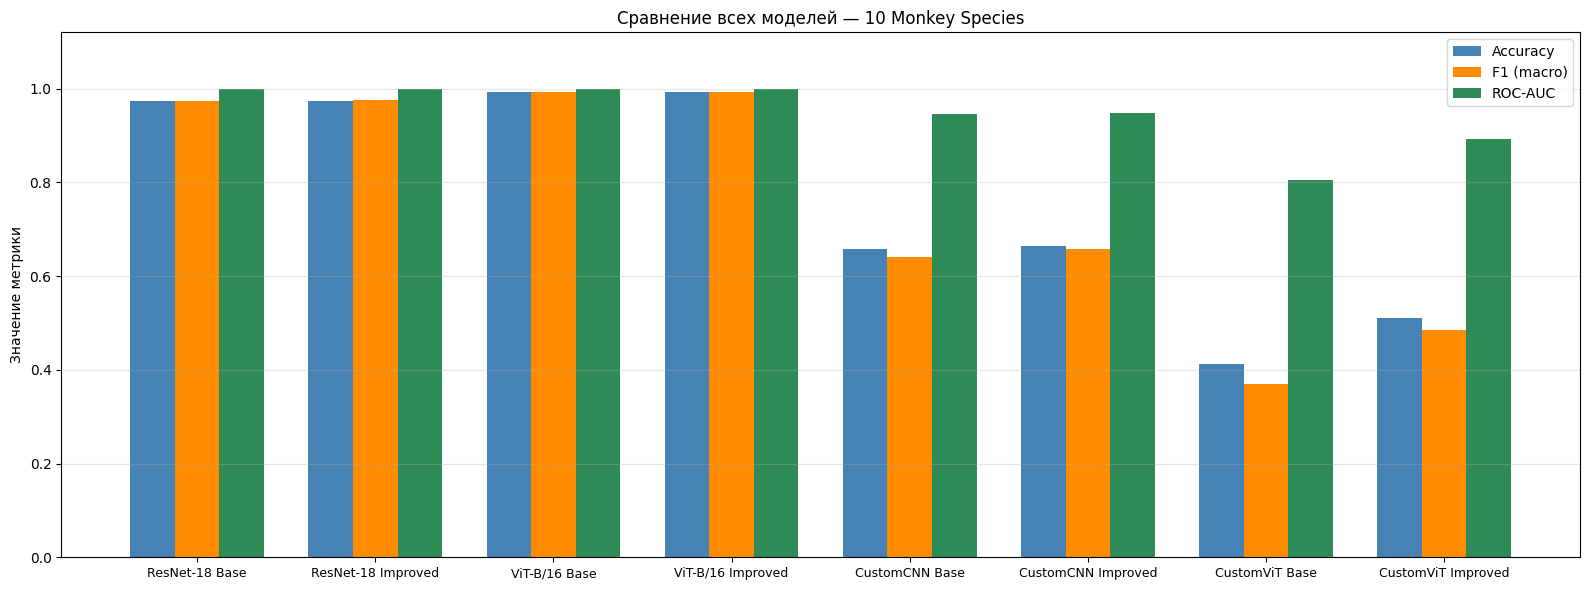


=== Итоговая таблица ===
Модель                           Accuracy   F1 (macro)    ROC-AUC
-----------------------------------------------------------------
ResNet-18 Base                     0.9745       0.9741     0.9998
ResNet-18 Improved                 0.9745       0.9762     0.9999
ViT-B/16 Base                      0.9927       0.9919     1.0000
ViT-B/16 Improved                  0.9927       0.9928     0.9999
CustomCNN Base                     0.6569       0.6402     0.9466
CustomCNN Improved                 0.6642       0.6570     0.9480
CustomViT Base                     0.4124       0.3695     0.8059
CustomViT Improved                 0.5109       0.4848     0.8914


In [33]:
import matplotlib.pyplot as plt

model_labels = [
    'ResNet-18 Base', 'ResNet-18 Improved',
    'ViT-B/16 Base',  'ViT-B/16 Improved',
    'CustomCNN Base', 'CustomCNN Improved',
    'CustomViT Base', 'CustomViT Improved',
]
accs  = [acc_rn, acc_rn_aug, acc_vit, acc_vit_aug, acc_cnn, acc_cnn_aug, acc_cvit, acc_cvit_aug]
f1s   = [f1_rn,  f1_rn_aug,  f1_vit,  f1_vit_aug,  f1_cnn,  f1_cnn_aug,  f1_cvit,  f1_cvit_aug]
aucs  = [auc_rn, auc_rn_aug, auc_vit, auc_vit_aug, auc_cnn, auc_cnn_aug, auc_cvit, auc_cvit_aug]

x = np.arange(len(model_labels))
w = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - w, accs, w, label='Accuracy',  color='steelblue')
ax.bar(x,     f1s,  w, label='F1 (macro)', color='darkorange')
ax.bar(x + w, aucs, w, label='ROC-AUC',   color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение всех моделей — 10 Monkey Species')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150)
plt.show()

print("\n=== Итоговая таблица ===")
print(f"{'Модель':<30} {'Accuracy':>10} {'F1 (macro)':>12} {'ROC-AUC':>10}")
print("-" * 65)
rows = zip(
    ['ResNet-18 Base','ResNet-18 Improved','ViT-B/16 Base','ViT-B/16 Improved',
     'CustomCNN Base','CustomCNN Improved','CustomViT Base','CustomViT Improved'],
    accs, f1s, aucs
)
for name, a, f, u in rows:
    print(f"{name:<30} {a:>10.4f} {f:>12.4f} {u:>10.4f}")

---
## 10. Визуализация предсказаний

── ResNet-18 Improved ──


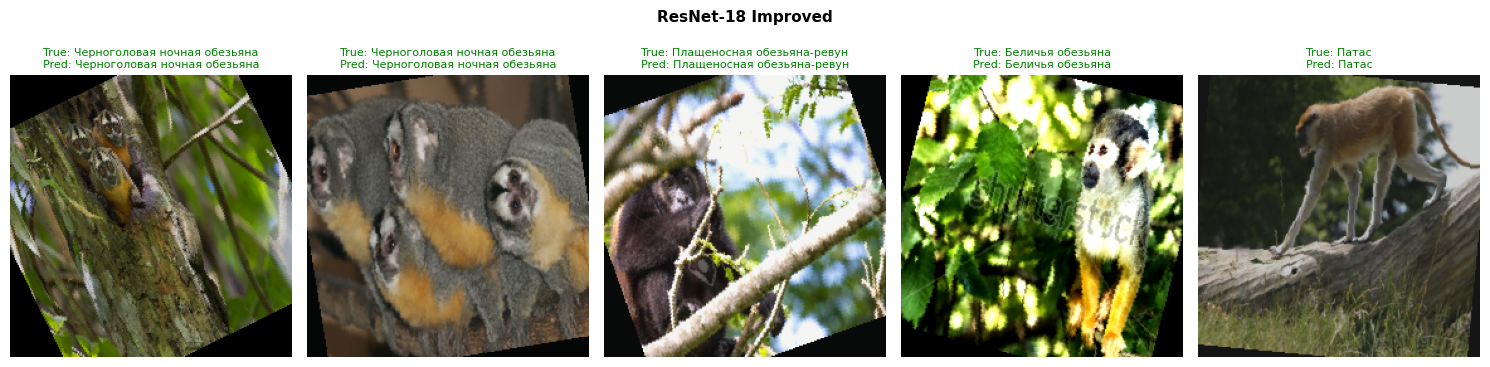

── ViT-B/16 Improved ──


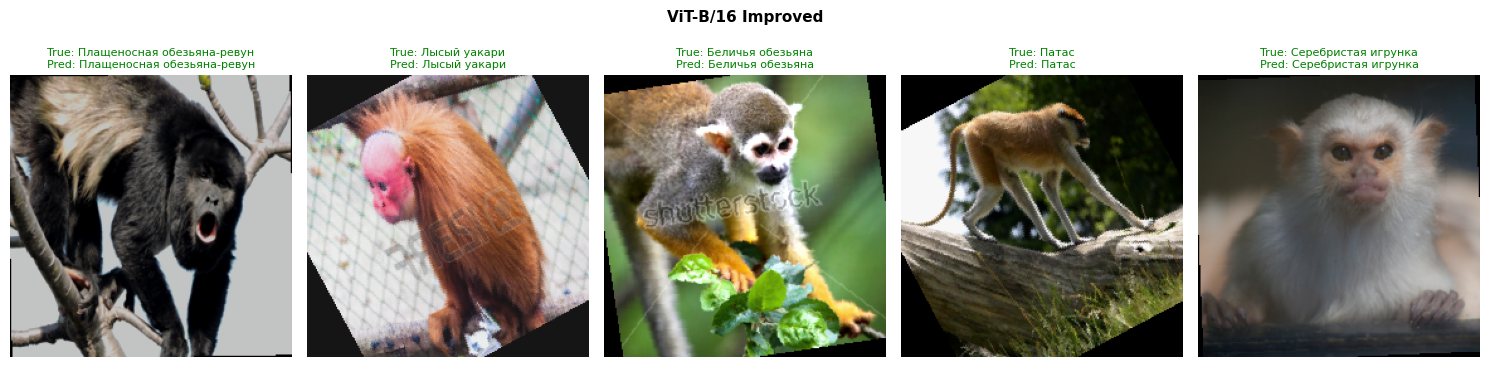

── CustomCNN Improved ──


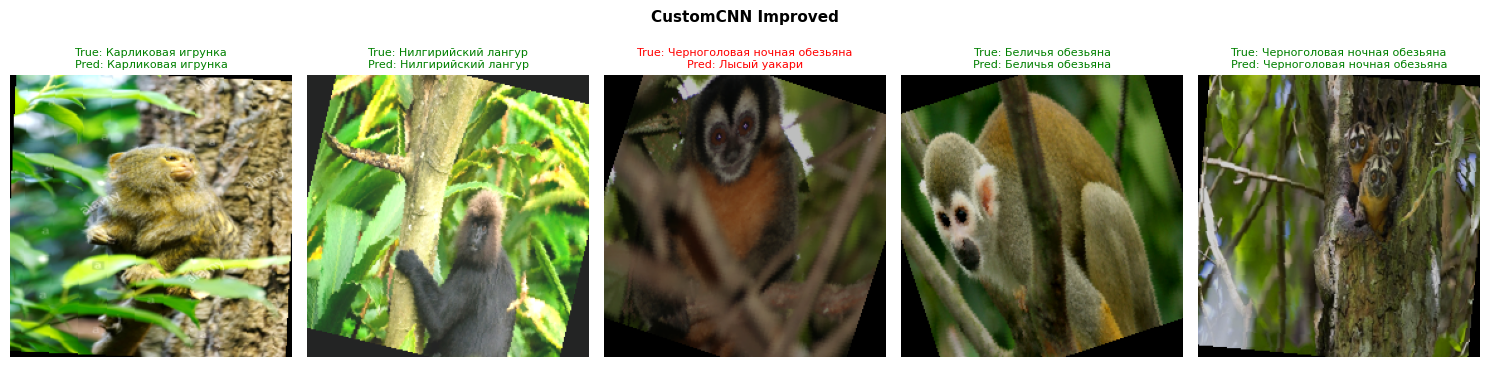

── CustomViT Improved ──


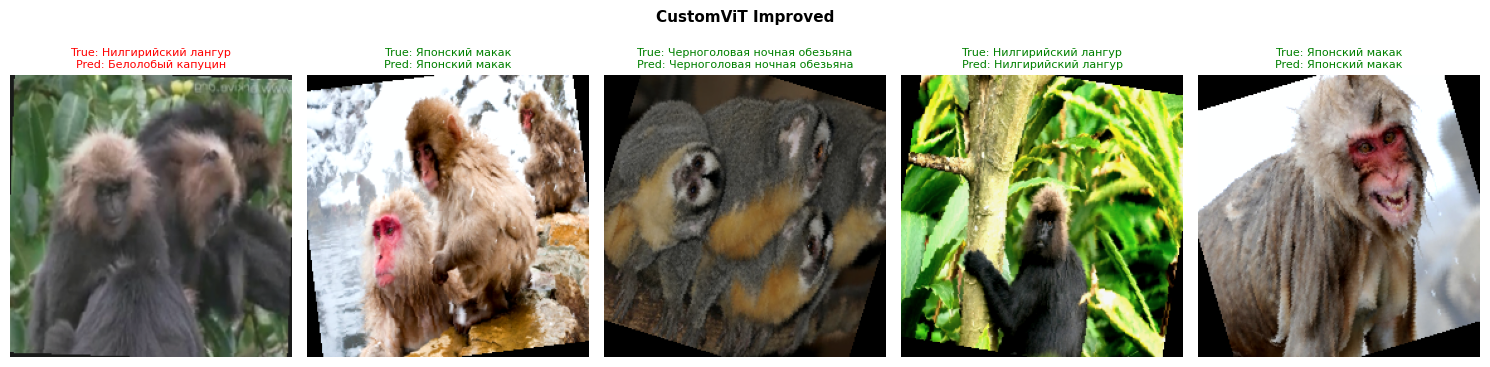

In [38]:
import random

MONKEY_NAMES = {
    'n0': 'Плащеносная обезьяна-ревун',
    'n1': 'Патас',
    'n2': 'Лысый уакари',
    'n3': 'Японский макак',
    'n4': 'Карликовая игрунка',
    'n5': 'Белолобый капуцин',
    'n6': 'Серебристая игрунка',
    'n7': 'Беличья обезьяна',
    'n8': 'Черноголовая ночная обезьяна',
    'n9': 'Нилгирийский лангур',
}


def visualize_predictions(model, loader, class_names, model_name: str, num_images: int = 5):
    """Отображение предсказаний модели на случайных изображениях.

    Args:
        model: Обученная модель PyTorch.
        loader: DataLoader с данными.
        class_names: Список имён классов.
        model_name: Название модели (заголовок).
        num_images: Число отображаемых изображений.
    """
    model.eval()
    images, labels = next(iter(loader))
    idx = random.sample(range(len(images)), min(num_images, len(images)))
    imgs, lbls = images[idx], labels[idx]

    with torch.no_grad():
        probs = torch.softmax(model(imgs.to(device)), dim=1)
        preds = torch.argmax(probs, dim=1).cpu()

    fig, axes = plt.subplots(1, num_images, figsize=(3 * num_images, 4))
    for i, ax in enumerate(axes):
        img = imgs[i].permute(1, 2, 0).numpy() * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)
        true_code = class_names[lbls[i]]
        pred_code = class_names[preds[i]]
        
        true_lbl = MONKEY_NAMES[true_code]
        pred_lbl = MONKEY_NAMES[pred_code]

        ax.imshow(img)
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}",
                     color='green' if true_lbl == pred_lbl else 'red', fontsize=8)
        ax.axis('off')
    fig.suptitle(model_name, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


for m, ldr, name in [
    (resnet_aug,   aug_val_loader, "ResNet-18 Improved"),
    (vit_aug,      aug_val_loader, "ViT-B/16 Improved"),
    (custom_cnn_aug, aug_val_loader, "CustomCNN Improved"),
    (custom_vit_aug, aug_val_loader, "CustomViT Improved"),
]:
    print(f"── {name} ──")
    visualize_predictions(m, ldr, class_names, name)

---
## 11. Общие выводы

1. **Transfer learning кардинально важен при малом датасете.** ~1400 изображений — слишком мало для обучения глубоких сетей с нуля; предобученные ResNet-18 и ViT-B/16 существенно превосходят CustomCNN и CustomViT.

2. **Объединение train+val с random_split(80/20) даёт честную оценку.** Оригинальный val (~54 изображения для 2 классов) приводил к 100% метрикам у torchvision-моделей — нерепрезентативный результат.

3. **Аугментации улучшают все архитектуры.** RandomCrop, Flip, Rotation, ColorJitter снижают переобучение; особенно заметный эффект на CustomCNN и CustomViT, обученных с нуля.

4. **ViT требует малого lr и warmup.** `OneCycleLR` с `max_lr=1e-4` и 10% warmup устраняет проблему коллапса в один класс у CustomViT. ViT-B/16 из torchvision стабилен при lr=2e-6 с `ReduceLROnPlateau`.

5. **Лучшая модель — ViT-B/16 с улучшенным бейзлайном.** Трансформерная архитектура при корректных гиперпараметрах достигает наивысших значений F1-macro и ROC-AUC на задаче fine-grain классификации 10 видов обезьян.